# PETase figure generation
access precalculated data from huggingface: https://huggingface.co/datasets/fmoorhof/selectzyme-app-data/tree/main/petase
make multifigure plot with the plotting objectives: query_term, PET, domain 

In [28]:
#!pip install --quiet huggingface-hub==1.2.3
from huggingface_hub import hf_hub_download
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm

In [29]:
def import_results(dataset_name: str) -> tuple[pd.DataFrame, np.ndarray, np.ndarray, np.ndarray]:
    """
    Imports and loads results from a dataset downloaded from Hugging Face Hub.
    Args:
        dataset_name (str): Name of the dataset to fetch from Hugging Face Hub.
    Returns:
        tuple: A tuple containing the following:
            - pd.DataFrame: DataFrame loaded from "df.parquet".
            - np.ndarray: Reduced feature matrix loaded from "x_red_mst_slc.npz".
            - np.ndarray: Minimum spanning tree (MST) loaded from "x_red_mst_slc.npz".
            - np.ndarray: Linkage matrix loaded from "x_red_mst_slc.npz".
    """
    # Download files from Hugging Face Hub
    df_path = hf_hub_download(repo_id="fmoorhof/selectzyme-app-data", 
                              filename=f"{dataset_name}/df.parquet", 
                              repo_type="dataset")
    npz_path = hf_hub_download(repo_id="fmoorhof/selectzyme-app-data", 
                               filename=f"{dataset_name}/x_red_mst_slc.npz", 
                               repo_type="dataset")

    # Load data
    df = pd.read_parquet(df_path)
    adata = np.load(npz_path)
    X_red = adata["X_red"]
    mst = adata["mst"]
    linkage = adata["linkage"]

    return df, X_red, mst, linkage

In [30]:
df, X_red, mst, linkage = import_results("petase")

# rename columns for better readability in plots
df.rename(columns={"query_term": "Enzyme family"}, inplace=True)
df.rename(columns={"PET": "PETase activity"}, inplace=True)
df.rename(columns={"domain": "Domain"}, inplace=True)

# renaming of certain classes
df["Enzyme family"] = df["Enzyme family"].replace({"IPR003140": "Carboxylesterases", "IPR013818": "Lipase", "PF01083": "Cutinases", "cd00312": "Esterase", "custom": "Literature"})
df["PETase activity"] = df["PETase activity"].replace({"unknown": "Unknown", "0.0": "False", "1.0": "True"})
df

,accession,reviewed,Enzyme family,xref_brenda,PETase activity,PCL,PET&PCL,length,sequence,ec,protein_name,organism_id,xref_pdb,marker_size,marker_symbol,species,Domain,kingdom,selected,cluster
0,59,True,Literature,custom,True,0.0,unknown,186,MAACTDIDVVSARGTFEPGTLGFIVGDPVYAALQKKVAGKSLSSYK...,unknown,unknown,unknown,unknown,14,cross,Unknown,Unknown,Unknown,False,-1
1,60,True,Literature,custom,True,0.0,unknown,268,MAADNPYQRGPDPTNASIEAATGPFAVGTQPIVGASGFGGGQIYYP...,unknown,unknown,unknown,unknown,14,cross,Unknown,Unknown,Unknown,False,-1
2,61,True,Literature,custom,False,0.0,unknown,285,MAALQQRTIDLLRTHQDTVVAQWSDQLAGSGQGQDGRLSTRELDAQ...,unknown,unknown,unknown,unknown,14,cross,Unknown,Unknown,Unknown,False,-1
3,62,True,Literature,custom,True,0.0,unknown,271,MAANPYERGPNPTDALLEARSGPFSVSEENVSRLSASGFGGGTIYY...,unknown,unknown,unknown,unknown,14,cross,Unknown,Unknown,Unknown,False,-1
4,63,True,Literature,custom,False,0.0,unknown,751,MADKCPFHNQAPKPNVAGSGTQNRDWWPDQLKLNILRQHTTVSNPL...,unknown,unknown,unknown,unknown,14,cross,Unknown,Unknown,Unknown,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105294,W9YFJ5,unreviewed,Carboxylesterases,unknown,Unknown,unknown,unknown,251,MSSNPSIPLASDFPASLEPIIHLPANNRSTNVVLFLPGLGDTVANF...,unknown,Phospholipase/carboxylesterase/thioesterase do...,1182542,unknown,6,circle,Capronia epimyces,Eukaryota,Fungi,False,-1
105295,X0NTA4,unreviewed,Carboxylesterases,unknown,Unknown,unknown,unknown,254,MPPRIPTEDDFSPLSSTLPHTLHFPSPPESTTTFLVLFHGLGDHDV...,unknown,Phospholipase/carboxylesterase/thioesterase do...,1089449,unknown,6,circle,Fusarium oxysporum,Eukaryota,Fungi,False,183
105296,X0RNN7,unreviewed,Carboxylesterases,unknown,Unknown,unknown,unknown,223,MSNYLDAVVVEHNPSQKKIDRAVIWLHGLGASGHDFEPVVPQLGLA...,unknown,Phospholipase/carboxylesterase family protein,1298608,unknown,6,circle,Psychrobacter sp. JCM 18900,Bacteria,Pseudomonadota,False,240
105297,X6MIT7,unreviewed,Carboxylesterases,unknown,Unknown,unknown,unknown,254,MALESQGNDSEIKSEAIKKTSTYKPYKLPFIIAPKKEVKHSATVIV...,unknown,Phospholipase,46433,unknown,6,circle,Reticulomyxa filosa,Eukaryota,Foraminifera,False,-1


In [31]:
# plotting instructions

def _ensure_xy_numeric(df):
    df = df.copy()
    for c in ["x", "y"]:
        if df[c].dtype == "object":
            df[c] = df[c].astype(str).str.replace(",", ".", regex=False)
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def _collapse_to_allowed_categories(
    s: pd.Series,
    allowed: list[str],
    other_label: str = "Others",
    na_label: str = "NA",
):
    """Collapse everything not in `allowed` into `other_label`."""
    s2 = s.astype(str).fillna(na_label)
    allowed_str = [str(a) for a in allowed]
    allowed_present = [a for a in allowed_str if (s2 == a).any()]

    s_collapsed = s2.where(s2.isin(set(allowed_str)), other_label)
    categories = allowed_present + ([other_label] if (s_collapsed == other_label).any() else [])
    return pd.Categorical(s_collapsed, categories=categories, ordered=False)

def _get_nature_cmap(K: int):
    """
    Muted, publication-style categorical palette with a *true discrete LUT*.

    Why not `plt.get_cmap("tab20c", K)`? `tab20c` only has 20 discrete colors.
    When you request more than that, Matplotlib effectively re-samples a stepwise map,
    which can yield repeated colors (identical RGBA) for multiple categories.
    """
    from matplotlib.colors import ListedColormap

    # Up to 60 distinct qualitative colors, stable across K
    base_colors: list = []
    for name in ("tab20", "tab20b", "tab20c"):
        cm = plt.get_cmap(name)
        if hasattr(cm, "colors"):
            base_colors.extend(list(cm.colors))
        else:
            # Fallback for non-Listed colormaps (shouldn't happen here, but safe)
            base_colors.extend([cm(i / 19) for i in range(20)])

    if K <= len(base_colors):
        colors = base_colors[:K]
    else:
        # Rare: if you truly have >60 classes, add extra hues deterministically.
        extra = plt.get_cmap("hsv")(np.linspace(0, 1, K - len(base_colors), endpoint=False))
        colors = base_colors + list(extra)

    return ListedColormap(colors[:K])

def _scatter_panel_categories(
    ax,
    df,
    col,
    *,
    x_col: str = "x",
    y_col: str = "y",
    point_size: float = 6,
    alpha: float = 0.75,
    allowed: list[str] | None = None,
    other_label: str = "Others",
    minority_on_top: bool = True,
    show_axis_labels: bool = True,
 ):
    """Scatter UMAP colored by `col` with optional collapsing and minority-on-top draw order."""
    if col not in df.columns:
        ax.set_title(f"{col} (missing)")
        ax.axis("off")
        return

    s = df[col]
    if allowed is not None:
        s_plot = _collapse_to_allowed_categories(
            s,
            allowed=allowed,
            other_label=other_label,
        )
        labels = list(s_plot.categories)
    else:
        # No collapsing: order legend by frequency (most abundant first).
        s2 = s.astype(str).fillna("NA")
        vc = s2.value_counts(dropna=False)
        labels = vc.index.tolist()
        s_plot = pd.Categorical(s2, categories=labels, ordered=False)

    x = df[x_col].to_numpy()
    y = df[y_col].to_numpy()

    # Integer codes 0..K-1 aligned to `labels`
    codes = pd.Series(s_plot).map({lab: i for i, lab in enumerate(labels)}).to_numpy()
    if np.any(pd.isna(codes)):
        codes = np.nan_to_num(codes, nan=0).astype(int)
    else:
        codes = codes.astype(int)

    # Draw order: plot majority first, minority last (on top).
    if minority_on_top and len(labels) > 1:
        s_vals = pd.Series(s_plot).astype(str)
        vc_plot = s_vals.value_counts(dropna=False)
        freq_per_point = s_vals.map(vc_plot).to_numpy()
        order = np.argsort(-freq_per_point, kind="mergesort")
        x = x[order]
        y = y[order]
        codes = codes[order]

    K = max(len(labels), 1)
    cmap = _get_nature_cmap(K)
    norm = BoundaryNorm(np.arange(-0.5, K + 0.5, 1), K)

    ax.scatter(
        x,
        y,
        c=codes,
        cmap=cmap,
        norm=norm,
        s=point_size,
        alpha=alpha,
        linewidths=0,
    )

    ax.grid(True, alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(top=False, right=False)

    if show_axis_labels:
        ax.set_xlabel("UMAP-1", fontsize=12)
        ax.set_ylabel("UMAP-2", fontsize=12)
    else:
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(labelleft=True, labelbottom=True)

    # Legend colors must match the discrete LUT exactly
    lut = np.asarray(cmap.colors)
    handles = []
    for i, lab in enumerate(labels):
        handles.append(
            plt.Line2D(
                [0],
                [0],
                marker="o",
                color="none",
                markerfacecolor=lut[i],
                markersize=6,
                alpha=alpha,
                label=lab,
            )
        )
    ax.legend(
        handles=handles,
        title=col,
        loc="upper right",
        bbox_to_anchor=(0.5, -0.15),
        ncol=1,
        frameon=False,
        fontsize=12,
        title_fontsize=12,
    )

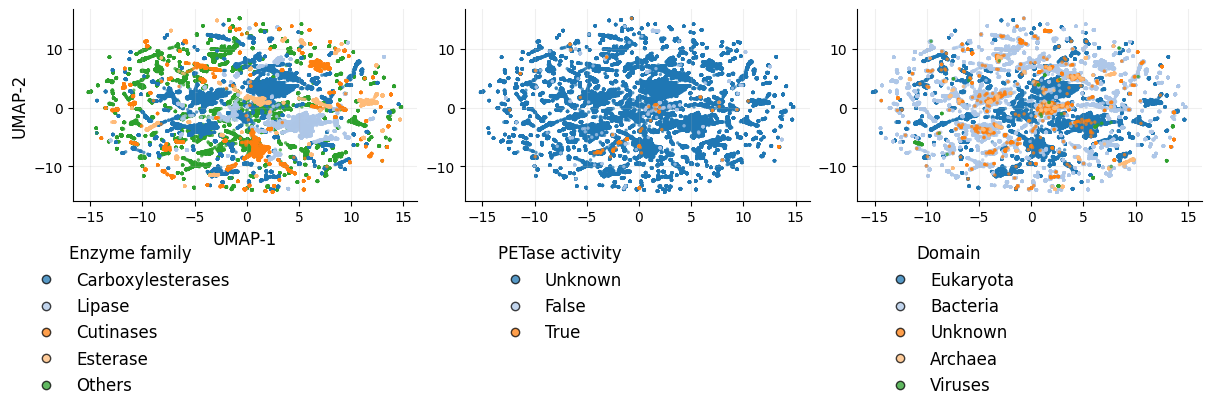

In [32]:
# plotting
assert len(df) == X_red.shape[0], "df and X_red must have the same number of rows"

plot_df = df[["accession", "Enzyme family", "PETase activity", "Domain"]].copy()
plot_df["x"] = X_red[:, 0]
plot_df["y"] = X_red[:, 1]

# Plot styling (muted publication palette + minority-on-top)
point_size = 6
alpha_val = 0.75

plot_df2 = _ensure_xy_numeric(plot_df).dropna(subset=["x", "y"]).copy()

# Square panels in a 1x3 layout: total width ~= 3 * height
fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 4),
    sharex=True,
    sharey=True,
    constrained_layout=True,
 )
axes = np.array(axes).reshape(-1)

# Only show these query_term labels; everything else -> 'Others'
query_term_allowed = ["Carboxylesterases", "Lipase", "Cutinases", "Esterase"]  # , "Literature"

_scatter_panel_categories(
    axes[0],
    plot_df2,
    "Enzyme family",
    point_size=point_size,
    alpha=alpha_val,
    allowed=query_term_allowed,
    other_label="Others",
    minority_on_top=True,
    show_axis_labels=True,
 )
_scatter_panel_categories(
    axes[1],
    plot_df2,
    "PETase activity",
    point_size=point_size,
    alpha=alpha_val,
    minority_on_top=True,
    show_axis_labels=False,
 )
_scatter_panel_categories(
    axes[2],
    plot_df2,
    "Domain",
    point_size=point_size,
    alpha=alpha_val,
    minority_on_top=True,
    show_axis_labels=False,
 )

plt.savefig("petase_plot.png", dpi=600)
# plt.savefig("petase_plot.svg")
plt.show()
